In [1]:
import pandas as pd
data = {
    "message": [
        "Congratulations! You won a free prize. Claim now!",
        "Win cash now! Click this link to get your reward.",
        "You have been selected for a free gift.",
        "URGENT! You won 10000 dollars. Call now.",
        "Get a free mobile recharge today!",
        "Hi, how are you?",
        "Please send me the assignment.",
        "I will come to college at 10 AM.",
        "Your class starts at 9 AM tomorrow.",
        "Can you call me when you reach home?"
    ],
        "label": [
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham"
    ]
}
df = pd.DataFrame(data)
print(df)

                                             message label
0  Congratulations! You won a free prize. Claim now!  spam
1  Win cash now! Click this link to get your reward.  spam
2            You have been selected for a free gift.  spam
3           URGENT! You won 10000 dollars. Call now.  spam
4                  Get a free mobile recharge today!  spam
5                                   Hi, how are you?   ham
6                     Please send me the assignment.   ham
7                   I will come to college at 10 AM.   ham
8                Your class starts at 9 AM tomorrow.   ham
9               Can you call me when you reach home?   ham


In [2]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df["clean_message"] = df["message"].apply(clean_text)
print(df[["message", "clean_message", "label"]])

                                             message  \
0  Congratulations! You won a free prize. Claim now!   
1  Win cash now! Click this link to get your reward.   
2            You have been selected for a free gift.   
3           URGENT! You won 10000 dollars. Call now.   
4                  Get a free mobile recharge today!   
5                                   Hi, how are you?   
6                     Please send me the assignment.   
7                   I will come to college at 10 AM.   
8                Your class starts at 9 AM tomorrow.   
9               Can you call me when you reach home?   

                                     clean_message label  
0   congratulations you won a free prize claim now  spam  
1  win cash now click this link to get your reward  spam  
2           you have been selected for a free gift  spam  
3                  urgent you won dollars call now  spam  
4                 get a free mobile recharge today  spam  
5                            

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_message"])

print("Number of messages:", X.shape[0])
print("Number of features:", X.shape[1])

Number of messages: 10
Number of features: 47


In [4]:
y = df["label"]
print(y)

0    spam
1    spam
2    spam
3    spam
4    spam
5     ham
6     ham
7     ham
8     ham
9     ham
Name: label, dtype: object


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training messages:", X_train.shape[0])
print("Testing messages:", X_test.shape[0])

Training messages: 8
Testing messages: 2


In [6]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)
print("Actual Labels:")
print(y_test.values)
print("\nPredicted Labels:")
print(y_pred)

Actual Labels:
['ham' 'spam']

Predicted Labels:
['ham' 'spam']


In [8]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [9]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 1]]


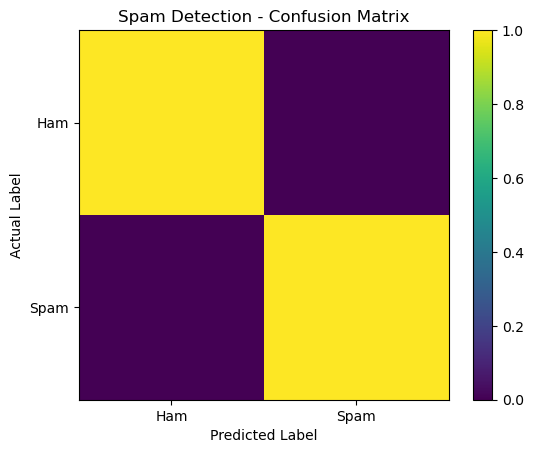

In [11]:
import matplotlib.pyplot as plt
plt.imshow(cm)
plt.title("Spam Detection - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()
plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])
plt.show()

In [12]:
message = input("Enter your SMS message: ")
cleaned_message = clean_text(message)
message_vector = vectorizer.transform([cleaned_message])
prediction = model.predict(message_vector)
if prediction[0] == "spam":
    print("\n🔴 Result: SPAM MESSAGE")
else:
    print("\n🟢 Result: HAM (NORMAL MESSAGE)")

Enter your SMS message:  Congratulations! You won a free prize. Claim now!



🔴 Result: SPAM MESSAGE


In [13]:
message = input("Enter your SMS message: ")
cleaned_message = clean_text(message)
message_vector = vectorizer.transform([cleaned_message])
prediction = model.predict(message_vector)
if prediction[0] == "spam":
    print("\n🔴 Result: SPAM MESSAGE")
else:
    print("\n🟢 Result: HAM (NORMAL MESSAGE)")

Enter your SMS message:  Hi, I will come to college tomorrow morning.



🟢 Result: HAM (NORMAL MESSAGE)


In [ ]:
import pandas as pd
df = pd.read_csv("spam.csv", encoding="latin-1")
print(df.head())
print(df.shape)
print(df.columns)
df = df[["v1", "v2"]]
df.columns = ["label", "message"]
print(df.head())
print(df["label"].value_counts())